# 09. Dual-Branch Feature Fusion Classification
**Objective:** Combine Convolutional Neural Networks (CNN) operating on the raw FFT magnitude with a Multi-Layer Perceptron (MLP) operating on Mini-Batch sparse codes to achieve state-of-the-art gesture recognition.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

sys.path.append(os.path.abspath('../'))
from src.config import PREPROCESSED_DIR, DEVICE
from src.frequency import extract_fft_magnitude
from src.dictionary_freq import FrequencyDictionaryLearner, FrequencyOMPExtractor
from src.fusion_net import DualBranchEMGNet, train_dual_branch_model

plt.style.use('seaborn-v0_8-whitegrid')

### 1. Load Data and Extract Respective Features

In [2]:
file_path = os.path.join(PREPROCESSED_DIR, "DB1_subject_1.h5")
with h5py.File(file_path, 'r') as f:
    X_bal = np.array(f['X'])
    y_bal = np.array(f['y']).astype(np.int64)
    reps_bal = np.array(f['reps'])

train_reps = [1, 2, 3, 4, 5, 6, 7]
test_reps = [8, 9, 10]

train_idx = np.where(np.isin(reps_bal, train_reps))[0]
test_idx = np.where(np.isin(reps_bal, test_reps))[0]

# Branch 1 Features: FFT Magnitude
X_freq = extract_fft_magnitude(X_bal)
X_freq_train, y_train = X_freq[train_idx], y_bal[train_idx]
X_freq_test, y_test = X_freq[test_idx], y_bal[test_idx]

# Branch 2 Features: Mini-Batch Sparse Codes
mb_learner = FrequencyDictionaryLearner(n_atoms=32, transform_n_nonzero_coefs=3, method='minibatch')
mb_learner.load_dictionary("emg_dict_minibatch_freq_S1.npz")
mb_extractor = FrequencyOMPExtractor(mb_learner.dictionary_, n_nonzero_coefs=3)

X_train_mb_raw = mb_extractor.transform(X_freq_train)
X_test_mb_raw = mb_extractor.transform(X_freq_test)

scaler = StandardScaler()
X_sparse_train = scaler.fit_transform(X_train_mb_raw)
X_sparse_test = scaler.transform(X_test_mb_raw)

print(f"Branch 1 (FFT) Shape: {X_freq_train.shape}")
print(f"Branch 2 (Sparse) Shape: {X_sparse_train.shape}")

Extracting FFT from input shape (18630, 20, 10)...
FFT extraction complete. Output shape: (18630, 10, 10)
Dictionary loaded from /workspaces/TCC/models/emg_dict_minibatch_freq_S1.npz


/home/vscode/.local/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:191: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  return func(*args, **kwargs)
/home/vscode/.local/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:191: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  return func(*args, **kwargs)


Branch 1 (FFT) Shape: (12664, 10, 10)
Branch 2 (Sparse) Shape: (12664, 320)


### 2. Initialize and Train the Dual-Branch Network

In [3]:
num_channels = X_freq_train.shape[2]
freq_bins = X_freq_train.shape[1]
sparse_dim = X_sparse_train.shape[1]
num_classes = int(max(y_train.max(), y_test.max()) + 1)

dual_model = DualBranchEMGNet(
    num_channels=num_channels,
    freq_bins=freq_bins,
    sparse_dim=sparse_dim,
    num_classes=num_classes
)

dual_model = train_dual_branch_model(
    model=dual_model,
    X_freq_train=X_freq_train,
    X_sparse_train=X_sparse_train,
    y_train=y_train,
    epochs=40,
    batch_size=64,
    lr=0.001
)

Training Dual-Branch Network on cuda...
Epoch 1/40 | Loss: 3.3121
Epoch 5/40 | Loss: 1.7649
Epoch 10/40 | Loss: 1.4591
Epoch 15/40 | Loss: 1.2879
Epoch 20/40 | Loss: 1.1795
Epoch 25/40 | Loss: 1.0983
Epoch 30/40 | Loss: 1.0321
Epoch 35/40 | Loss: 0.9670
Epoch 40/40 | Loss: 0.9231


### 3. Evaluate Dual-Branch Network

In [4]:
dual_model.eval()
with torch.no_grad():
    X_f_te = torch.FloatTensor(X_freq_test).transpose(1, 2).to(DEVICE)
    X_s_te = torch.FloatTensor(X_sparse_test).to(DEVICE)
    
    raw_outputs = dual_model(X_f_te, X_s_te)
    dual_preds = torch.argmax(raw_outputs, dim=1).cpu().numpy()

dual_acc = accuracy_score(y_test, dual_preds)
dual_f1 = f1_score(y_test, dual_preds, average='macro')

print("\n--- Dual-Branch Fusion Network Results ---")
print(f"Accuracy: {dual_acc * 100:.2f}%")
print(f"Macro F1-Score: {dual_f1 * 100:.2f}%")


--- Dual-Branch Fusion Network Results ---
Accuracy: 51.87%
Macro F1-Score: 50.48%


### 4. Confusion Matrix

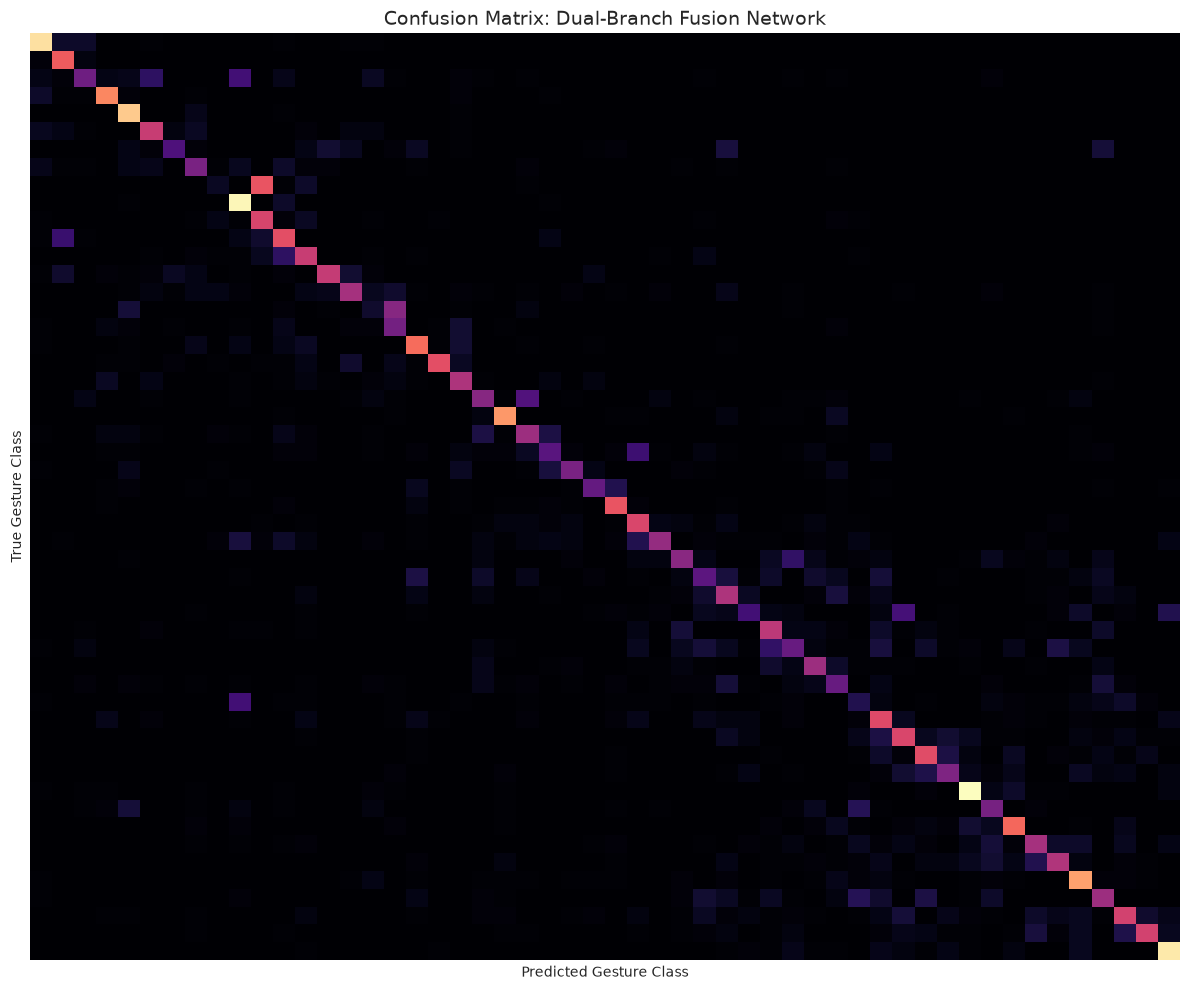

In [5]:
conf_matrix = confusion_matrix(y_test, dual_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, cmap='magma', cbar=False, xticklabels=False, yticklabels=False)
plt.title("Confusion Matrix: Dual-Branch Fusion Network", fontsize=14)
plt.xlabel("Predicted Gesture Class")
plt.ylabel("True Gesture Class")
plt.tight_layout()
plt.show()